In [1]:
# Google Colab-only setup — run this notebook in its own fresh Colab runtime.
import sys
if "google.colab" not in sys.modules:
    raise RuntimeError(
        "This session 1 is Google Colab-only. Open https://colab.research.google.com/, "
        "upload this notebook, and run it there."
    )

%pip install -q ultralytics==8.4.102 matplotlib numpy pillow

import torch
torch.manual_seed(0)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.1 MB/s eta 0:00:00


In [2]:
# Independent Colab assets — this notebook never reads another session's files.
from pathlib import Path
import os

SESSION_WORKSPACE = Path("/content/yolo_object_detection_session_01")
SESSION_WORKSPACE.mkdir(parents=True, exist_ok=True)
os.chdir(SESSION_WORKSPACE)

from ultralytics import YOLO, settings
from ultralytics.data.utils import check_det_dataset

SESSION_DATASETS = SESSION_WORKSPACE / "datasets"
settings.update({"datasets_dir": str(SESSION_DATASETS)})
COCO128_INFO = check_det_dataset("coco128.yaml", autodownload=True)
COCO128_YAML = Path(COCO128_INFO.get("yaml_file", "coco128.yaml"))
BASELINE_MODEL = YOLO("yolo11n.pt")  # Downloads and caches this notebook's pretrained weights.
print(f"Colab-only session 1: workspace={SESSION_WORKSPACE} | dataset={COCO128_YAML} | model=yolo11n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/yolo_object_detection_session_01/datasets/coco128/images/train2017'
Unzipping /content/yolo_object_detection_session_01/datasets/coco128.zip to /content/yolo_object_detection_session_01/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 1.8Kfiles/s 0.1s
Dataset download success ✅ (0.7s), saved to /content/yolo_object_detection_session_01/datasets

Colab-only session 1: workspace=/content/yolo_object_detection_session_01 | dataset=/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/datasets/coco128.yaml | model=yolo11n.pt


## 1. Record the environment

A result is easier to reproduce when its package version, checkpoint, device, and random seed are recorded.

In [3]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import os
import random
import tempfile
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
IS_COLAB = "google.colab" in sys.modules
CHECKPOINT = os.environ.get("YOLO_CHECKPOINT", "yolo11n.pt")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
try:
    ULTRALYTICS_VERSION = version("ultralytics")
    ULTRALYTICS_AVAILABLE = True
except PackageNotFoundError:
    ULTRALYTICS_VERSION = "not installed (fallback mode)"
    ULTRALYTICS_AVAILABLE = False

print({
    "seed": SEED, "python": sys.version.split()[0], "torch": torch.__version__,
    "ultralytics": ULTRALYTICS_VERSION, "checkpoint": CHECKPOINT, "device": DEVICE
})

{'seed': 42, 'python': '3.12.13', 'torch': '2.11.0+cpu', 'ultralytics': '8.4.102', 'checkpoint': 'yolo11n.pt', 'device': 'cpu'}


## 2. Inventory downloaded COCO128

COCO128 follows the Ultralytics detection layout: a dataset YAML names the classes and train split, `images/` holds photographs, and same-stem files under `labels/` hold one object per row. This notebook uses the downloaded COCO128 labels directly.

In [4]:
# Use only the COCO128 copy downloaded by this notebook's Colab bootstrap.
YAML_PATH = COCO128_YAML
IMAGE_DIR = Path(COCO128_INFO["train"])
COCO_ROOT = Path(COCO128_INFO["path"])
relative_split = IMAGE_DIR.relative_to(COCO_ROOT / "images")
LABEL_DIR = COCO_ROOT / "labels" / relative_split
CLASS_NAMES = COCO128_INFO["names"]
if isinstance(CLASS_NAMES, list):
    CLASS_NAMES = dict(enumerate(CLASS_NAMES))
DATA_MODE = "COCO128 downloaded in this notebook"

print("Dataset mode:", DATA_MODE)
print("YAML:", YAML_PATH)
print("Images:", IMAGE_DIR)
print("Labels:", LABEL_DIR)
print("Classes:", CLASS_NAMES)
# Build only verified image–label pairs. COCO128 archives can contain orphan labels,
# so never derive an image path from a label without checking it exists first.
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
image_by_stem = {path.stem: path for path in IMAGE_DIR.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES}
all_label_paths = sorted(LABEL_DIR.rglob("*.txt"))
label_paths = [path for path in all_label_paths if path.stem in image_by_stem]
missing_image_labels = [path for path in all_label_paths if path.stem not in image_by_stem]
image_paths = [image_by_stem[path.stem] for path in label_paths]
all_rows = []
for label_path in label_paths:
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        if line.strip():
            all_rows.append((label_path, line_number, line.strip()))

print(f"Verified {len(image_paths)} image–label pairs; skipped {len(missing_image_labels)} orphan label file(s).")
print(f"Found {len(all_rows)} label rows in verified pairs.")
print("Three raw label examples:")
for path, line_number, row in all_rows[:3]:
    print(f"  {path.name}:{line_number}  {row}")
assert len(image_paths) >= 3 and len(all_rows) >= 3, "COCO128 download is incomplete."


Dataset mode: COCO128 downloaded in this notebook
YAML: /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/datasets/coco128.yaml
Images: /content/yolo_object_detection_session_01/datasets/coco128/images/train2017
Labels: /content/yolo_object_detection_session_01/datasets/coco128/labels/train2017
Classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47

In [5]:
# Build only verified image–label pairs. COCO128 archives can contain orphan labels,
# so never derive an image path from a label without checking it exists first.
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}
image_by_stem = {path.stem: path for path in IMAGE_DIR.rglob("*") if path.suffix.lower() in IMAGE_SUFFIXES}
all_label_paths = sorted(LABEL_DIR.rglob("*.txt"))
label_paths = [path for path in all_label_paths if path.stem in image_by_stem]
missing_image_labels = [path for path in all_label_paths if path.stem not in image_by_stem]
image_paths = [image_by_stem[path.stem] for path in label_paths]
all_rows = []
for label_path in label_paths:
    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        if line.strip():
            all_rows.append((label_path, line_number, line.strip()))

print(f"Verified {len(image_paths)} image–label pairs; skipped {len(missing_image_labels)} orphan label file(s).")
print(f"Found {len(all_rows)} label rows in verified pairs.")
print("Three raw label examples:")
for path, line_number, row in all_rows[:3]:
    print(f"  {path.name}:{line_number}  {row}")
assert len(image_paths) >= 3 and len(all_rows) >= 3, "COCO128 download is incomplete."


Verified 126 image–label pairs; skipped 2 orphan label file(s).
Found 929 label rows in verified pairs.
Three raw label examples:
  000000000009.txt:1  45 0.479492 0.688771 0.955609 0.5955
  000000000009.txt:2  45 0.736516 0.247188 0.498875 0.476417
  000000000009.txt:3  50 0.637063 0.732938 0.494125 0.510583


## 3. Decode one label by hand

For a `640 × 480` image, consider `2 0.5 0.5 0.5 0.5`. The normalized center becomes `(320, 240)` pixels and the size becomes `(320, 240)` pixels. Half the width/height extends on each side, so the corners are `(160, 120, 480, 360)`. No `+1` is used because we treat boxes as half-open geometric rectangles.

In [6]:
supplied = "2 0.5 0.5 0.5 0.5"
_, x_center_n, y_center_n, width_n, height_n = supplied.split()
W, H = 640, 480
x_center, y_center = float(x_center_n) * W, float(y_center_n) * H
box_width, box_height = float(width_n) * W, float(height_n) * H
hand_corners = (x_center-box_width/2, y_center-box_height/2, x_center+box_width/2, y_center+box_height/2)
print(f"center=({x_center:.0f}, {y_center:.0f}), size=({box_width:.0f}, {box_height:.0f})")
print("corners (x1, y1, x2, y2) =", hand_corners)
assert hand_corners == (160.0, 120.0, 480.0, 360.0)

center=(320, 240), size=(320, 240)
corners (x1, y1, x2, y2) = (160.0, 120.0, 480.0, 360.0)


## 4. Exercise E1 — convert normalized center-size to pixel corners

Complete the four equations. Keep floating-point corners: rounding is a separate display decision.

In [7]:
# TODO: Return (x1, y1, x2, y2) in pixels from normalized center-size values.
# HINT: Multiply x/width quantities by image_width and y/height by image_height.

def normalized_center_to_corners(x_center_n, y_center_n, width_n, height_n, image_width, image_height):
    x_center = x_center_n * image_width
    y_center = y_center_n * image_height
    box_width = width_n * image_width
    box_height = height_n * image_height

    x1 = x_center - box_width / 2
    y1 = y_center - box_height / 2
    x2 = x_center + box_width / 2
    y2 = y_center + box_height / 2

    return x1, y1, x2, y2


## 5. Exercise E2 — validate before decoding

A decoder should fail loudly on bad annotations. Add checks for the five-field layout, class ID, finite normalized values, allowed range, and positive dimensions. A valid box is asserted to stay inside the image instead of being silently clipped.

In [8]:
# TODO: Parse and validate one YOLO row, then return (class_id, x1, y1, x2, y2).
# HINT: Reject wrong field counts, invalid class IDs/ranges, non-finite values, and nonpositive sizes.
def decode_yolo_row(row, image_width, image_height, number_of_classes):
    fields = row.split()
    assert len(fields) == 5, f"Expected 5 fields, received {len(fields)}: {row!r}"

    raw_class, *raw_values = fields
    class_number = float(raw_class)
    assert class_number.is_integer(), f"Class ID must be an integer: {raw_class}"

    class_id = int(class_number)
    assert 0 <= class_id < number_of_classes, (
        f"Class ID {class_id} outside [0, {number_of_classes})"
    )

    values = np.asarray([float(value) for value in raw_values], dtype=float)
    assert np.isfinite(values).all(), f"Normalized values must be finite: {raw_values}"
    assert (0.0 <= values).all() and (values <= 1.0).all(), (
        f"Normalized values outside [0, 1]: {raw_values}"
    )

    x_center_n, y_center_n, width_n, height_n = values
    assert width_n > 0 and height_n > 0, (
        f"Width and height must be positive: {width_n}, {height_n}"
    )

    x1, y1, x2, y2 = normalized_center_to_corners(
        *values, image_width, image_height
    )

    normalized_tolerance = 1e-6  # Labels are commonly rounded to six decimal places.
    x_tolerance = normalized_tolerance * image_width
    y_tolerance = normalized_tolerance * image_height

    assert -x_tolerance <= x1 < x2 <= image_width + x_tolerance, (
        f"Decoded x corners outside image: {(x1, x2)}"
    )
    assert -y_tolerance <= y1 < y2 <= image_height + y_tolerance, (
        f"Decoded y corners outside image: {(y1, y2)}"
    )

    return class_id, x1, y1, x2, y2

In [ ]:
# Audit every nonempty label row programmatically.
for label_path, line_number, row in all_rows:
    with Image.open(image_by_stem[label_path.stem]) as image:
        decode_yolo_row(row, image.width, image.height, len(CLASS_NAMES))
print(f"Validated all {len(all_rows)} rows.")

# Malformed examples should trigger clear assertions.
malformed = {
    "wrong field count": "0 0.5 0.5 0.2",
    "invalid class": f"{len(CLASS_NAMES)} 0.5 0.5 0.2 0.2",
    "range error": "0 1.2 0.5 0.2 0.2",
    "nonpositive width": "0 0.5 0.5 0.0 0.2",
}
for description, row in malformed.items():
    try:
        decode_yolo_row(row, 640, 480, len(CLASS_NAMES))
        raise RuntimeError(f"Malformed row unexpectedly passed: {description}")
    except AssertionError as error:
        print(f"Caught {description}: {error}")

## 6. Visualize three ground-truth label sets

The picture is the final geometry check. A mathematically valid box can still surround the wrong object if files were paired incorrectly.

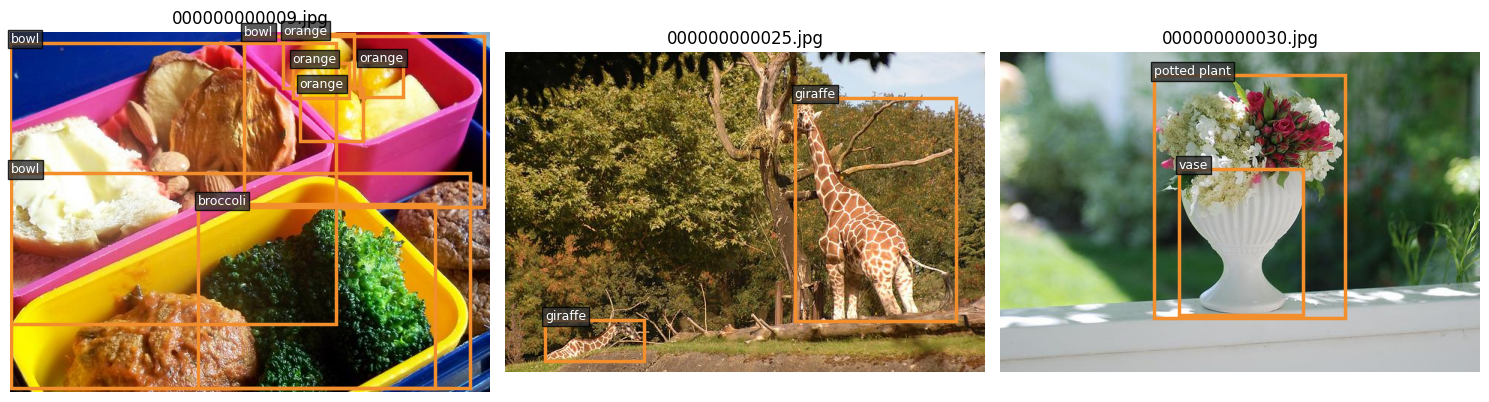

In [9]:
def matching_label_path(image_path):
    return LABEL_DIR / f"{image_path.stem}.txt"

def ground_truth_for(image_path):
    with Image.open(image_path) as opened:
        width, height = opened.size
    label_path = matching_label_path(image_path)
    rows = label_path.read_text(encoding="utf-8").splitlines() if label_path.exists() else []
    return [decode_yolo_row(row, width, height, len(CLASS_NAMES)) for row in rows if row.strip()]

selected_images = [path for path in image_paths if matching_label_path(path).exists()][:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, image_path in zip(axes, selected_images):
    image = Image.open(image_path).convert("RGB")
    axis.imshow(image); axis.set_title(image_path.name); axis.axis("off")
    for class_id, x1, y1, x2, y2 in ground_truth_for(image_path):
        axis.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, ec="#f28e2b", lw=2.5))
        axis.text(x1, y1, CLASS_NAMES[class_id], color="white", fontsize=9,
                  bbox={"facecolor": "#333333", "alpha": 0.8, "pad": 2})
plt.tight_layout()

## 7. Run pretrained inference on the same images

A detection is one `(class, confidence, xyxy)` record. The number of records may differ across images—even zero is valid. In fallback mode, deterministic pseudo-predictions keep the output contract visible; they are **not** model results.

In [10]:
CONFIDENCE_THRESHOLD = 0.25
checkpoint_path = Path(CHECKPOINT).expanduser()
REAL_INFERENCE = ULTRALYTICS_AVAILABLE and (IS_COLAB or checkpoint_path.exists())

if REAL_INFERENCE:
    from ultralytics import YOLO
    model = YOLO(CHECKPOINT)
    raw_results = model.predict([str(path) for path in selected_images], conf=CONFIDENCE_THRESHOLD, device=DEVICE, verbose=False)
    prediction_rows = []
    rendered_images = []
    for image_path, result in zip(selected_images, raw_results):
        rows = []
        for box in result.boxes:
            class_id = int(box.cls.item())
            confidence = float(box.conf.item())
            corners = tuple(float(value) for value in box.xyxy[0].tolist())
            rows.append((result.names[class_id], confidence, corners))
        prediction_rows.append(rows)
        rendered_images.append(result.plot()[..., ::-1])  # Ultralytics BGR -> RGB
    INFERENCE_MODE = f"Ultralytics {ULTRALYTICS_VERSION}, {CHECKPOINT}"
else:
    prediction_rows = []
    rendered_images = []
    for image_path in selected_images:
        image = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(image)
        rows = []
        for index, (class_id, x1, y1, x2, y2) in enumerate(ground_truth_for(image_path)):
            # Fixed offsets make a visible, reproducible label/prediction disagreement.
            dx, dy = 5 + 2*index, 3 + index
            corners = (x1+dx, y1+dy, x2+dx, y2+dy)
            confidence = 0.88 - 0.09*index
            rows.append((CLASS_NAMES[class_id], confidence, corners))
            draw.rectangle(corners, outline=(170, 40, 40), width=3)
            draw.text((corners[0], max(0, corners[1]-12)), f"{CLASS_NAMES[class_id]} {confidence:.2f}", fill=(120, 0, 0))
        prediction_rows.append(rows)
        rendered_images.append(np.asarray(image))
    INFERENCE_MODE = "deterministic pseudo-predictions (offline validation only)"

print("Inference mode:", INFERENCE_MODE)
print("Confidence threshold:", CONFIDENCE_THRESHOLD)
for image_path, rows in zip(selected_images, prediction_rows):
    print(f"\n{image_path.name}: {len(rows)} detection(s)")
    for class_name, confidence, corners in rows:
        rounded = tuple(round(value, 1) for value in corners)
        print(f"  class={class_name:<12} confidence={confidence:.3f} xyxy={rounded}")

Inference mode: Ultralytics 8.4.102, yolo11n.pt
Confidence threshold: 0.25

000000000009.jpg: 5 detection(s)
  class=bowl         confidence=0.929 xyxy=(308.9, 0.7, 630.4, 236.8)
  class=broccoli     confidence=0.841 xyxy=(255.0, 229.6, 567.5, 476.0)
  class=bowl         confidence=0.778 xyxy=(0.1, 189.6, 637.4, 474.4)
  class=bowl         confidence=0.617 xyxy=(1.0, 7.7, 433.0, 393.4)
  class=broccoli     confidence=0.374 xyxy=(328.1, 410.0, 427.5, 479.6)

000000000025.jpg: 1 detection(s)
  class=giraffe      confidence=0.877 xyxy=(368.6, 63.7, 601.7, 358.0)

000000000030.jpg: 2 detection(s)
  class=vase         confidence=0.908 xyxy=(237.8, 156.0, 407.9, 350.7)
  class=potted plant confidence=0.644 xyxy=(203.4, 32.2, 459.9, 350.3)


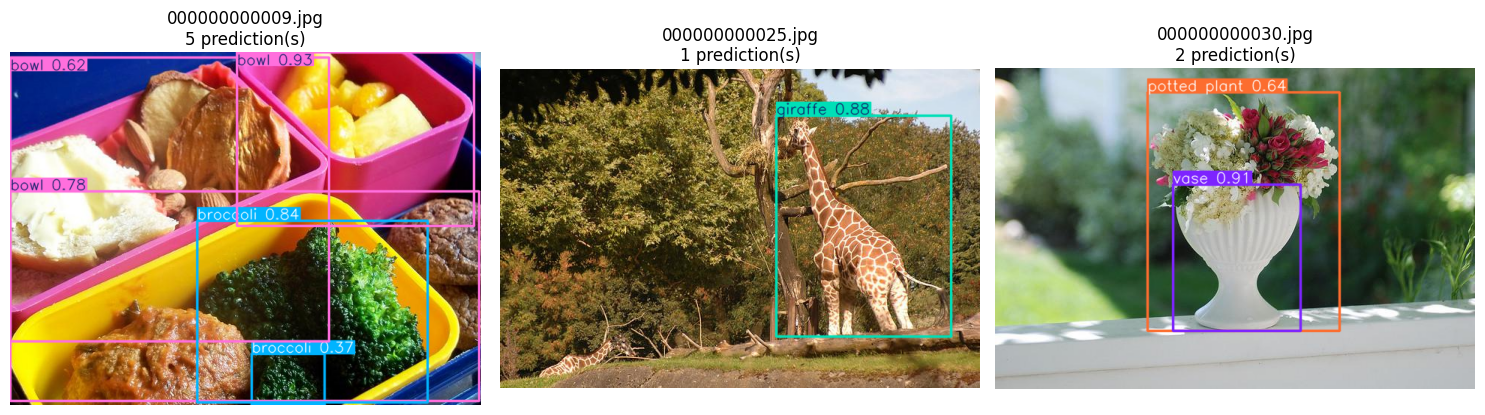

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, image_path, rendered in zip(axes, selected_images, rendered_images):
    axis.imshow(rendered); axis.set_title(f"{image_path.name}\n{len(prediction_rows[axes.tolist().index(axis)])} prediction(s)"); axis.axis("off")
plt.tight_layout()

## 8. Compare the three tasks

Describe their outputs and annotation types, not just their applications.

> TODO: Write exactly three sentences: one each for classification, semantic segmentation, and detection.


**Clasificación** asigna una única etiqueta de clase a toda la imagen sin indicar dónde se encuentra el objeto.

**Segmentación semántica** asigna una etiqueta de clase a cada píxel, produciendo una máscara que delimita las regiones de los objetos.

**Detección de objetos** predice cuadros delimitadores (bounding boxes), etiquetas de clase y puntuaciones de confianza para cada objeto detectado en la imagen.

## 9. Exercise E3 — explain one disagreement

Compare one label and prediction. Do not declare either one wrong before checking the image, annotation policy, threshold, class mapping, and localization evidence.

> TODO: Explain one label/prediction disagreement in 2–3 evidence-aware sentences.


En la primera imagen, el modelo detectó varios bowls y piezas de brócoli con diferentes niveles de confianza. Si alguna caja no coincide exactamente con la anotación de referencia, esto puede deberse a pequeñas diferencias en la localización de los objetos o a que algunos recipientes contienen varios alimentos, lo que dificulta definir sus límites exactos. La imagen y las etiquetas deben revisarse antes de concluir que existe un error.

## Wrap-up

You audited YOLO's five-field annotation format, converted normalized center-size values to pixel corners, rejected malformed rows, visualized three ground-truth examples, and inspected variable-length detection records. The central habit is simple: **check the label language visually before interpreting model behavior**.

**Concept check:** Why is `0.5` a different geometric quantity in the second, fourth, and fifth fields of `2 0.5 0.5 0.5 0.5`?

Aunque los tres valores son 0.5, representan cantidades geométricas distintas. El segundo campo indica la posición horizontal normalizada del centro de la caja con respecto al ancho de la imagen, mientras que el cuarto y el quinto campo representan el ancho y la altura normalizados de la caja delimitadora. Es decir, un mismo valor numérico describe propiedades diferentes según el campo en el que aparece.